In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad("/nfs/users/nfs_d/dp26/nfs_storage/Megagut/cell2location_run/result_hgca_visium/c2l_map_hgca_ct1_only/Gut_Visium_healthy_adult_4_samples.h5ad")

In [7]:
adata.obs[adata.uns['mod']['factor_names']] = adata.obsm['q05_cell_abundance_w_sf']

In [9]:
adata

AnnData object with n_obs × n_vars = 8867 × 17318
    obs: 'in_tissue', 'array_row', 'array_col', 'batch', '_indices', '_scvi_batch', '_scvi_labels', 'Adipocytes', 'Angiogenic Pericytes', 'Arteriolar Endothelial', 'BEST4 Colonocytes', 'BEST4 Enterocytes', 'Brunners Gland Cells', 'CD4 Memory', 'CD4 Naive', 'CD4 Tfh', 'CD4 Tfr', 'CD4 Th17', 'CD4 Tr1', 'CD4 pTreg', 'CD4 tTreg', 'CD8 Circulating Effector Memory', 'CD8 Effector Memory', 'CD8 IEL', 'CD8 Memory Exhausted', 'CD8 Naive', 'CD8 TRM', 'Capillary Endothelial', 'Classical Monocytes', 'Colonocyte Progenitors', 'Contractile Pericytes', 'Crypt Bottom Fibroblasts (S2A)', 'Crypt Top Colonocytes', 'Crypt Top Fibroblasts (S2B)', 'Cycling Macrophages', 'EEC Enterochromaffin (EC)', 'EEC L', 'EEC N', 'EEC Progenitors', 'EEC S', 'Enterocyte Progenitors', 'Enteroendocrine Cells (EEC)', 'Eosinophils', 'Epithelial', 'Fibroblastic Reticular Cells (FRC)', 'Follicle Associated Resident Macrophages', 'Follicular Dendritic Cells (fDC)', 'Foveolar Cell

In [18]:
import numpy as np
def select_slide(adata, s, batch_key="sample"):
    r"""This function selects the data for one slide from the spatial anndata object.

    :param adata: Anndata object with multiple spatial experiments
    :param s: name of selected experiment
    :param batch_key: column in adata.obs listing experiment name for each location
    """

    slide = adata[adata.obs[batch_key].isin([s]), :].copy()
    s_keys = list(slide.uns["spatial"].keys())
    s_spatial = np.array(s_keys)[[s in k for k in s_keys]][0]

    slide.uns["spatial"] = {s_spatial: slide.uns["spatial"][s_spatial]}

    return slide


In [14]:
list(adata.obs.batch.unique())

['spaceranger311_count_36090_WSSS_A_GUTsp9518708_1_GRCh38-2020-A',
 'spaceranger311_count_36090_WSSS_A_GUTsp9518709_1_GRCh38-2020-A',
 'spaceranger311_count_36090_WSSS_A_GUTsp9518707_1_GRCh38-2020-A',
 'spaceranger311_count_36090_WSSS_A_GUTsp9518706_1_GRCh38-2020-A']

In [19]:
slide = select_slide(adata, 'spaceranger311_count_36090_WSSS_A_GUTsp9518708_1_GRCh38-2020-A',batch_key='batch')

In [23]:
slide.obsm['spatial'] = slide.obsm['spatial'].astype(float)

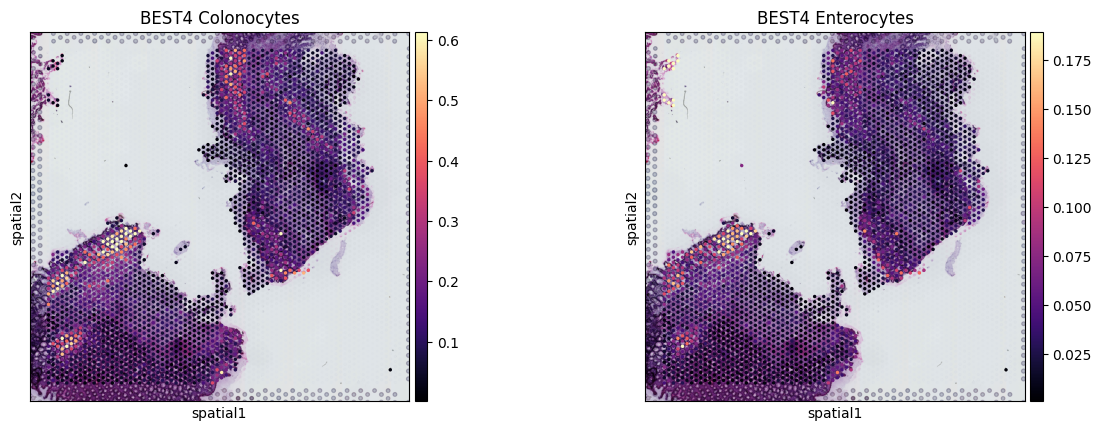

In [25]:
sc.pl.spatial(slide,color=['BEST4 Colonocytes', 'BEST4 Enterocytes'],vmax='p99',cmap='magma')